# Семинар: Physics-Informed Neural Networks (PINNs)
В этом семинаре мы:
- Решим **прямую задачу**: получим решение уравнения теплопроводности
- Решим **обратную задачу**: восстановим коэффициент теплопроводности из разреженных экспериментальных данных

---

## Задача: Уравнение теплопроводности

Рассмотрим 1D уравнение теплопроводности:

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad x \in [0, 1], \ t \in [0, 1]
$$

Начальные условия: $u(x, 0) = \sin(\pi x)$  
Граничные условия: $u(0, t) = u(1, t) = 0$

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available()
    else "cpu")

## Класс модели PINN

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

        alpha = torch.tensor([0.1], dtype=torch.float32)
        self.register_parameter("alpha", nn.Parameter(alpha))

    def forward(self, x):
        return self.model(x)

Выполнение уравнения

In [3]:
def pde_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    inputs = torch.cat([x, t], dim=1)
    u = model(inputs)

    u_t = grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    return u_t - model.alpha * u_xx

def analytical_solution(x, t, alpha):
    return torch.exp(-np.pi**2 * alpha * t) * torch.sin(np.pi * x)

### **Прямая задача (Forward Problem)**

В прямой задаче решается классическая задача Коши для одномерного уравнения теплопроводности. Коэффициент теплопроводности $\alpha$ известен, положим $\alpha = 0.01$.

Хотим найти функцию $u(x, t)$, удовлетворяющую начальным, граничным условиям и уравнению теплопроводности.

#### Метод:

* Нейросеть $u_\theta(x, t)$ обучается за счёт минимизации следующей функции потерь:

$$
\mathcal{L}_{\text{Total}} = \mathcal{L}_{\text{IC}} + \mathcal{L}_{\text{BC}} + \mathcal{L}_{\text{PDE}}
$$

где

$$
\mathcal{L}_{\text{IC}} = \frac{1}{N_{\text{IC}}} \sum_{i=1}^{N_{\text{IC}}} \left(u_\theta(x_i, 0) - \sin(\pi x_i)\right)^2
$$

$$
\mathcal{L}_{\text{BC}} = \frac{1}{N_{\text{BC}}} \sum_{i=1}^{N_{\text{BC}}} \left(u_\theta(0, t_i)^2 + u_\theta(1, t_i)^2\right)
$$

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N_{\text{PDE}}} \sum_{i=1}^{N_{\text{PDE}}} \left( \frac{\partial u_\theta}{\partial t}(x_i, t_i) - \alpha \frac{\partial^2 u_\theta}{\partial x^2}(x_i, t_i) \right)^2
$$



In [15]:
def initial_condition(x):
    return torch.sin(np.pi * x)

def boundary_condition(t):
    return torch.zeros_like(t)

def train_forward(model, n_ic=100, n_bc=100, n_pde=5000, epochs=3000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    x_ic = torch.rand(n_ic, 1).to(device)
    t_ic = torch.zeros_like(x_ic).to(device)
    u_ic = initial_condition(x_ic).to(device)

    t_bc = torch.rand(n_bc, 1).to(device)
    x_bc_0 = torch.zeros_like(t_bc).to(device)
    x_bc_1 = torch.ones_like(t_bc).to(device)

    x_pde = torch.rand(n_pde, 1).to(device)
    t_pde = torch.rand(n_pde, 1).to(device)

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # IC loss
        u_ic_pred = model(torch.cat([x_ic, t_ic], dim=1))
        loss_ic = nn.MSELoss()(u_ic_pred, u_ic)

        # BC loss
        u_bc_0 = model(torch.cat([x_bc_0, t_bc], dim=1))
        u_bc_1 = model(torch.cat([x_bc_1, t_bc], dim=1))
        loss_bc = nn.MSELoss()(u_bc_0, boundary_condition(t_bc)) + nn.MSELoss()(u_bc_1, boundary_condition(t_bc))

        # PDE residual loss
        res_pde = pde_residual(model, x_pde, t_pde)
        loss_pde = torch.mean(res_pde**2)

        loss = loss_ic + loss_bc + loss_pde
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"[Epoch {epoch}] Loss: {loss.item():.5f}, Loss_ic: {loss_ic.item():.5f}, Loss_bc: {loss_bc.item():.5f}, Loss_pde: {loss_pde.item():.5f}")

        losses.append(loss.item())

    return losses

[Epoch 0] Loss: 0.83350, Loss_ic: 0.78717, Loss_bc: 0.04550, Loss_pde: 0.00083
[Epoch 100] Loss: 0.28806, Loss_ic: 0.19367, Loss_bc: 0.06668, Loss_pde: 0.02772
[Epoch 200] Loss: 0.00511, Loss_ic: 0.00206, Loss_bc: 0.00045, Loss_pde: 0.00260
[Epoch 300] Loss: 0.00191, Loss_ic: 0.00073, Loss_bc: 0.00019, Loss_pde: 0.00099
[Epoch 400] Loss: 0.00070, Loss_ic: 0.00017, Loss_bc: 0.00008, Loss_pde: 0.00045
[Epoch 500] Loss: 0.00030, Loss_ic: 0.00003, Loss_bc: 0.00004, Loss_pde: 0.00023
[Epoch 600] Loss: 0.00015, Loss_ic: 0.00001, Loss_bc: 0.00002, Loss_pde: 0.00012
[Epoch 700] Loss: 0.00008, Loss_ic: 0.00000, Loss_bc: 0.00001, Loss_pde: 0.00007
[Epoch 800] Loss: 0.00004, Loss_ic: 0.00000, Loss_bc: 0.00001, Loss_pde: 0.00004
[Epoch 900] Loss: 0.00003, Loss_ic: 0.00000, Loss_bc: 0.00000, Loss_pde: 0.00002
[Epoch 1000] Loss: 0.00002, Loss_ic: 0.00000, Loss_bc: 0.00000, Loss_pde: 0.00001
[Epoch 1100] Loss: 0.00001, Loss_ic: 0.00000, Loss_bc: 0.00000, Loss_pde: 0.00001
[Epoch 1200] Loss: 0.00001, 

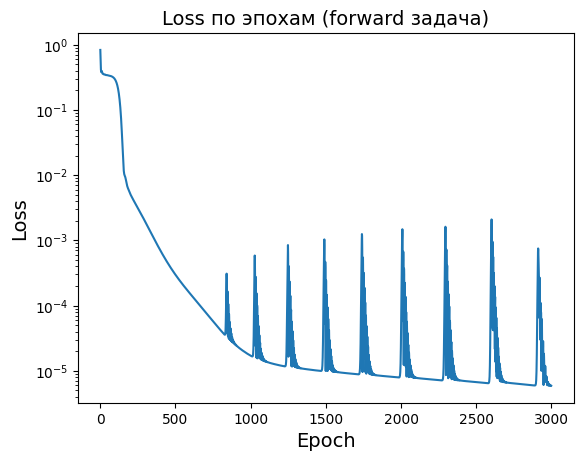

In [16]:
model_forward = PINN().to(device)
model_forward.alpha.data = torch.tensor([0.01], device=device)  # фиксируем известный alpha
model_forward.alpha.requires_grad = False  # не обучаем alpha в прямой задаче

losses_forward = train_forward(model_forward)

plt.plot(losses_forward)
plt.title("Loss по эпохам (forward задача)", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.yscale("log")
plt.show()

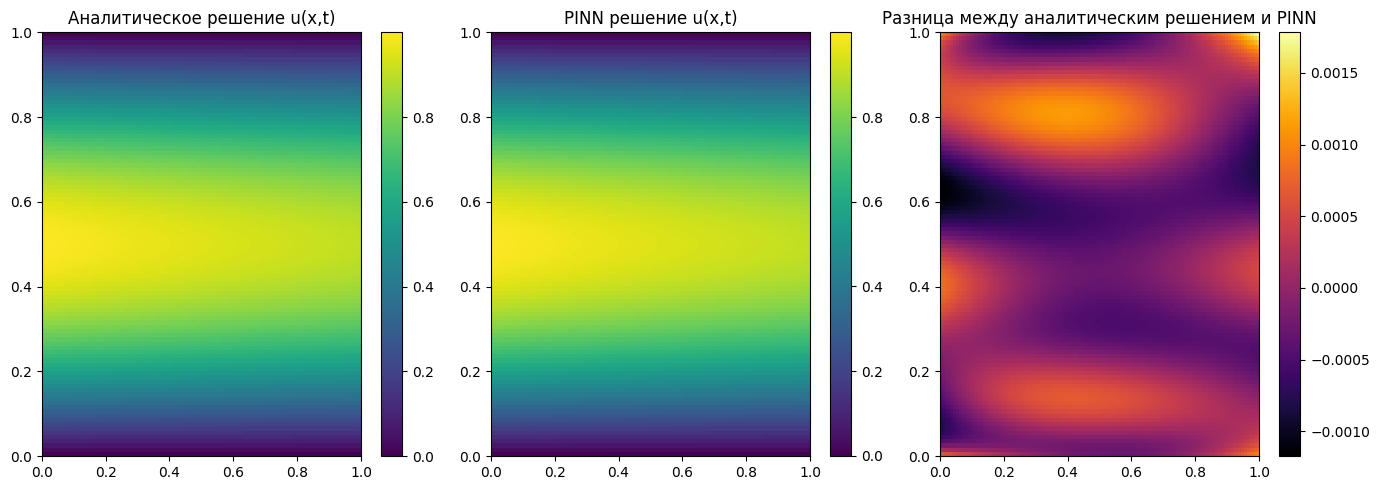

In [10]:
# Создание сетки
x_grid = torch.linspace(0, 1, 100).reshape(-1, 1)
t_grid = torch.linspace(0, 1, 100).reshape(-1, 1)
x_mesh, t_mesh = torch.meshgrid(x_grid.squeeze(), t_grid.squeeze(), indexing='ij')
x_flat = x_mesh.reshape(-1, 1).to(device)
t_flat = t_mesh.reshape(-1, 1).to(device)

# Аналитическое решение
u_exact = analytical_solution(x_flat, t_flat, alpha=0.01).cpu().detach().numpy().reshape(100, 100)

# PINN решение
with torch.no_grad():
    u_pred = model_forward(torch.cat([x_flat, t_flat], dim=1)).cpu().numpy().reshape(100, 100)

# Визуализация
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

c1 = axs[0].imshow(u_exact, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axs[0].set_title("Аналитическое решение u(x,t)")
fig.colorbar(c1, ax=axs[0])

c2 = axs[1].imshow(u_pred, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axs[1].set_title("PINN решение u(x,t)")
fig.colorbar(c2, ax=axs[1])

c3 = axs[2].imshow(u_pred - u_exact, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='inferno')
axs[2].set_title("Разница между аналитическим решением и PINN")
fig.colorbar(c3, ax=axs[2])

plt.tight_layout()
plt.show()

### **Обратная задача (Inverse Problem)**

В обратной задаче предполагается, что коэффициент теплопроводности $\alpha$ неизвестен, и его необходимо оценить.

У нас есть наблюдаемые значения функции $u(x, t)$ в ограниченном числе точек: $$\{(x_i, t_i, u_i^{\text{obs}})\}_{i=1}^{N_{\text{obs}}}$$

Хотим восстановить значение $\alpha$ по наблюдаемым данным.

#### Метод:

Обучаем нейросеть $u_\theta(x, t)$ и оптимизируем параметр $\alpha$, минимизируя:

$$
\mathcal{L}_{\text{Total}} = \mathcal{L}_{\text{data}} + \mathcal{L}_{\text{PDE}}
$$

где

$$
\mathcal{L}_{\text{data}} = \frac{1}{N_{\text{obs}}} \sum_{i=1}^{N_{\text{obs}}} \left(u_\theta(x_i, t_i) - u_i^{\text{obs}}\right)^2
$$

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N_{\text{PDE}}} \sum_{i=1}^{N_{\text{PDE}}} \left( \frac{\partial u_\theta}{\partial t}(x_i, t_i) - \alpha \frac{\partial^2 u_\theta}{\partial x^2}(x_i, t_i) \right)^2
$$



In [11]:
def generate_data_points(n_obs, n_pde):
    x_obs = torch.rand(n_obs, 1)
    t_obs = torch.rand(n_obs, 1)
    x_pde = torch.rand(n_pde, 1)
    t_pde = torch.rand(n_pde, 1)
    return x_obs, t_obs, x_pde, t_pde

In [12]:
def train_inverse(model, n_obs=200, n_pde=5000, epochs=3000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    x_obs, t_obs, x_pde, t_pde = generate_data_points(n_obs, n_pde)
    x_obs = x_obs.to(device)
    t_obs = t_obs.to(device)
    x_pde = x_pde.to(device)
    t_pde = t_pde.to(device)

    u_obs = analytical_solution(x_obs, t_obs, alpha=0.01).detach().to(device)

    losses, alphas = [], []

    for epoch in range(epochs):
        optimizer.zero_grad()

        res_pde = pde_residual(model, x_pde, t_pde)
        loss_pde = torch.mean(res_pde ** 2)

        u_pred = model(torch.cat([x_obs, t_obs], dim=1))
        loss_data = nn.MSELoss()(u_pred, u_obs)

        loss = loss_pde + loss_data
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"[Epoch {epoch}] Loss: {loss.item():.5f}, alpha: {model.alpha.item():.5f}")

        losses.append(loss.item())
        alphas.append(model.alpha.item())

    return model.alpha.item(), losses, alphas

## Запуск и визуализация результатов

In [13]:
model_inverse = PINN().to(device)
estimated_alpha, losses, alphas = train_inverse(model_inverse)

[Epoch 0] Loss: 0.57291, alpha: 0.09900
[Epoch 100] Loss: 0.08534, alpha: 0.08888
[Epoch 200] Loss: 0.06764, alpha: 0.07530
[Epoch 300] Loss: 0.00227, alpha: -0.00021
[Epoch 400] Loss: 0.00084, alpha: 0.00155
[Epoch 500] Loss: 0.00039, alpha: 0.00328
[Epoch 600] Loss: 0.00023, alpha: 0.00446
[Epoch 700] Loss: 0.00014, alpha: 0.00572
[Epoch 800] Loss: 0.00008, alpha: 0.00711
[Epoch 900] Loss: 0.00005, alpha: 0.00817
[Epoch 1000] Loss: 0.00004, alpha: 0.00872
[Epoch 1100] Loss: 0.00003, alpha: 0.00899
[Epoch 1200] Loss: 0.00003, alpha: 0.00916
[Epoch 1300] Loss: 0.00002, alpha: 0.00930
[Epoch 1400] Loss: 0.00002, alpha: 0.00940
[Epoch 1500] Loss: 0.00002, alpha: 0.00949
[Epoch 1600] Loss: 0.00001, alpha: 0.00957
[Epoch 1700] Loss: 0.00001, alpha: 0.00964
[Epoch 1800] Loss: 0.00001, alpha: 0.00968
[Epoch 1900] Loss: 0.00001, alpha: 0.00973
[Epoch 2000] Loss: 0.00001, alpha: 0.00977
[Epoch 2100] Loss: 0.00000, alpha: 0.00980
[Epoch 2200] Loss: 0.00000, alpha: 0.00982
[Epoch 2300] Loss: 0.0


 Полученное значение alpha: 0.00995


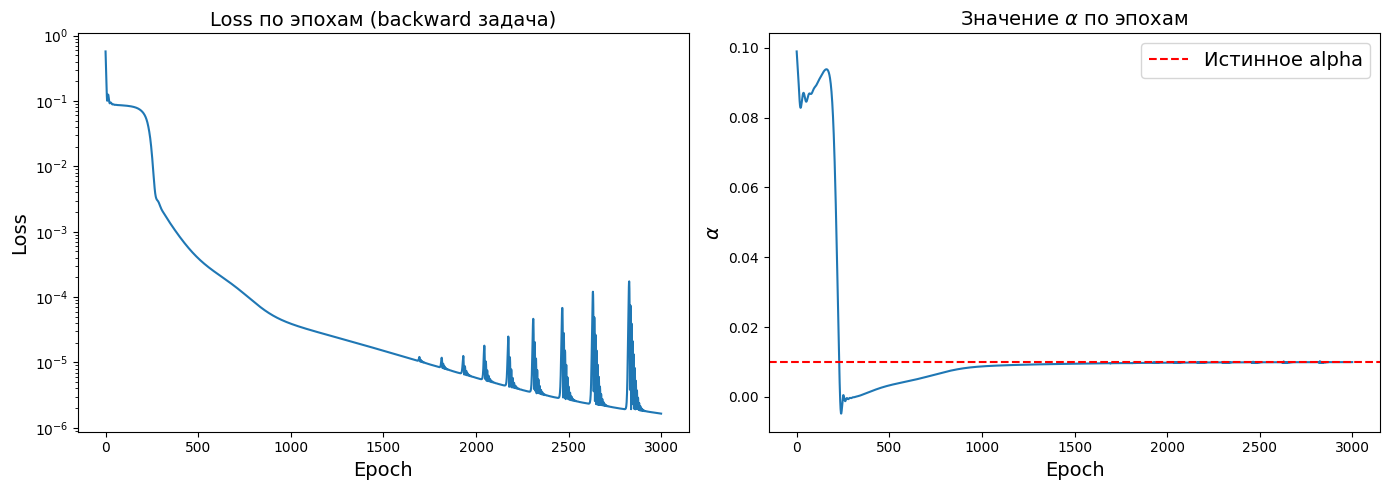

In [14]:
print(f"\n Полученное значение alpha: {estimated_alpha:.5f}")

# Визуализация
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.yscale("log")
plt.title("Loss по эпохам (backward задача)", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)

plt.subplot(1, 2, 2)
plt.plot(alphas)
plt.axhline(y=0.01, color='r', linestyle='--', label='Истинное alpha')
plt.title(r"Значение $\alpha$ по эпохам", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel(r"$\alpha$", fontsize=14)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()